In [74]:
# ================================================================
# CELL 0 — CONFIG (Modular control of all hyperparameters)
# ================================================================

CONFIG = {
    # Environment
    "gamma":          0.85,
    "cost_sigma":     0.2,       # 0.2 = low noise, 2.0 = high noise

    # Training
    "num_episodes":   3000,
    "num_runs":       10,
    "max_steps":      300,
    "lr_omega":       0.8,       # lr = (1/visit_count)^omega
    
    # Exploration
    "eps_start":      0.4,
    "eps_decay":      0.9,       # multiplied each step within episode

    # G-Learning
    "beta_min":       0.1,
    "beta_max":       15.0,    # was 7.0

    # TRPO
    "trpo_delta":     0.01,      # KL constraint threshold
    "trpo_alpha_c":   0.01,       # was 0.1, TRPO critic learning rate
    "trpo_bt_steps":  10,        # line search backtrack iterations
    "trpo_bt_ratio":  0.5,       # step size shrink per backtrack

    # Actor-Critic
    "ac_alpha_c":     0.01,      # was 0.05, critic learning rate    
    "ac_alpha_a":    0.001,      # was 0.005,    actor learning rate

    # REINFORCE
    "rf_alpha":       0.01,

    # Metrics
    "pe_every":       50,        # compute policy_eval every N episodes (slow)

    # Misc
    "seed":           42,
    "save_path":      "../results/",

    "algos": [
        "q_learning", "sarsa", "expected_sarsa", "double_q",
        "g_learning", "reinforce", "actor_critic", "trpo"
    ],
}


LABELS = {
    "q_learning":     "Q-Learning",
    "sarsa":          "SARSA",
    "expected_sarsa": "Exp. SARSA",
    "double_q":       "Double Q",
    "g_learning":     "G-Learning",
    "reinforce":      "REINFORCE",
    "actor_critic":   "Actor-Critic",
    "trpo":           "TRPO (Tabular)",
}

COLORS = {
    "q_learning":     "#1f77b4",
    "sarsa":          "#ff7f0e",
    "expected_sarsa": "#2ca02c",
    "double_q":       "#d62728",
    "g_learning":     "#9467bd",
    "reinforce":      "#8c564b",
    "actor_critic":   "#e377c2",
    "trpo":           "#17becf",
}

**Necessary Libraries and Dependencies**

In [75]:
# ================================================================
# CELL 1 — IMPORTS
# ================================================================

import numpy as np
import random
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
os.makedirs(CONFIG["save_path"], exist_ok=True)

if CONFIG["seed"] is not None:
    np.random.seed(CONFIG["seed"])
    random.seed(CONFIG["seed"])

print("✓ Imports done")

✓ Imports done


**Environment Defined as a Class**

In [76]:
# ================================================================
# CELL 2 — ENVIRONMENT
# ================================================================

class GridWorldEnv:
    """
    8x8 Stochastic Gridworld — Fox et al. (2016).
    Terminal: [4,4]. 15 blocked cells. 70% stay, 30% random drift.
    """
    DELTAS = {
        0:(-1,0), 1:(-1,1), 2:(0,1),  3:(1,1),
        4:(1,0),  5:(1,-1), 6:(0,-1), 7:(-1,-1), 8:(0,0)
    }
    DRIFT = [
        (0.050,(-1,0)),  (0.075,(-1,1)), (0.125,(0,1)),
        (0.150,(1,1)),   (0.200,(1,0)),  (0.225,(1,-1)),
        (0.275,(0,-1)),  (0.300,(-1,-1))
    ]

    def __init__(self):
        self.sigma = CONFIG["cost_sigma"]
        self.state = None
        self.inv_state = [
            [1,1],[1,4],[2,1],[2,4],[3,1],[3,4],[3,5],[3,6],
            [4,1],[4,2],[4,6],[5,2],[5,6],[6,2],[6,6]
        ]

    def _blocked(self, r, c):
        return [r, c] in self.inv_state

    def _out(self, r, c):
        return not (0 <= r <= 7 and 0 <= c <= 7)

    def step(self, action):
        r, c   = self.state
        r0, c0 = r, c
        cost   = 0.0

        if [r, c] == [4, 4]:
            return np.array([r, c]), 0.0, True, {}

        # Intended move
        dr, dc = self.DELTAS[action]
        r += dr; c += dc
        cost += 1 + np.random.normal(0, self.sigma)

        if [r, c] == [4, 4]:
            self.state = np.array([r, c])
            return self.state, cost, True, {}

        if self._out(r, c) or self._blocked(r, c):
            r, c   = r0, c0
            cost  += 10 + np.random.normal(0, self.sigma)

        # Stochastic drift
        r_pre, c_pre = r, c
        rnd = np.random.uniform()
        for thresh, (dr2, dc2) in self.DRIFT:
            if rnd <= thresh:
                rn, cn = r + dr2, c + dc2
                if not self._out(rn, cn) and not self._blocked(rn, cn):
                    if [rn, cn] != [r, c]:
                        cost += 1 + np.random.normal(0, self.sigma)
                    r, c = rn, cn
                break

        if [r, c] == [4, 4]:
            self.state = np.array([r, c])
            return self.state, cost, True, {}

        self.state = np.array([r, c])
        return self.state, cost, False, {}

    def reset(self):
        inv_flat = {i*8+j for i,j in self.inv_state}
        while True:
            k = np.random.randint(64)
            r, c = k // 8, k % 8
            if k not in inv_flat and [r, c] != [4, 4]:
                break
        self.state = np.array([r, c])
        return self.state

    def reset_to(self, state):
        self.state = np.array(state, dtype=int)
        return self.state

env = GridWorldEnv()
print("✓ Environment ready")

✓ Environment ready


**Building the transition function and the cost function**

In [77]:
# ================================================================
# CELL 3 — ANALYTICAL MODEL: P, C, V*, POLICY EVAL
# ================================================================

N_S = 64
N_A = 9
GAMMA = CONFIG["gamma"]

# Index mappings
S2I = {(i, j): i*8+j for i in range(8) for j in range(8)}
I2S = {i*8+j: (i, j) for i in range(8) for j in range(8)}
INV_FLAT  = {9,17,25,33,34,42,50,12,20,28,29,30,38,46,54}
TERMINAL  = 36   # flat index of [4,4]
VALID_STS = [s for s in range(N_S) if s not in INV_FLAT and s != TERMINAL]

DELTAS_A = {
    0:(-1,0), 1:(-1,1), 2:(0,1),  3:(1,1),
    4:(1,0),  5:(1,-1), 6:(0,-1), 7:(-1,-1), 8:(0,0)
}
DRIFT_PROBS = [
    ((-1,0),0.050), ((-1,1),0.025), ((0,1),0.050), ((1,1),0.025),
    ((1,0),0.050),  ((1,-1),0.025), ((0,-1),0.050),((-1,-1),0.025)
]

# Build P[s',s,a] and C[s',s,a]
P = np.zeros((N_S, N_S, N_A))
C = np.zeros((N_S, N_S, N_A))

for a in range(N_A):
    for s in range(N_S):
        if s in INV_FLAT:
            continue
        r0, c0 = I2S[s]
        if s == TERMINAL:
            P[s, s, a] = 1.0
            continue

        # Intended move
        dr, dc = DELTAS_A[a]
        r1, c1 = r0+dr, c0+dc
        if a == 8 or not (0<=r1<=7 and 0<=c1<=7) or S2I[(r1,c1)] in INV_FLAT:
            r1, c1 = r0, c0
        s_mid = S2I[(r1, c1)]

        if s_mid == TERMINAL:
            P[TERMINAL, s, a] = 1.0
            C[TERMINAL, s, a] = 1.0
            continue

        # Drift
        p_sum = 0.0
        for (dr2, dc2), prob in DRIFT_PROBS:
            r2, c2 = r1+dr2, c1+dc2
            if 0 <= r2 <= 7 and 0 <= c2 <= 7:
                s2 = S2I[(r2, c2)]
                if s2 not in INV_FLAT:
                    P[s2, s, a] += prob
                    C[s2, s, a]  = 2.0 if s2 != s_mid else 1.0
                    p_sum        += prob

        P[s_mid, s, a] += (1.0 - p_sum)
        C[s_mid, s, a]  = 1.0

# Expected immediate cost: AvC[s,a] = Σ_{s'} P[s',s,a]*C[s',s,a]
AvC = np.sum(P * C, axis=0)   # shape (64, 9)

# Optimal values (hardcoded from value iteration)
V_STAR = np.array([
    4.4098,3.8096,3.8096,3.8096,3.8096,4.4098,4.9311,5.3873,
    4.4098,0,    3.0288,3.0288,0,     4.4098,4.9311,5.3873,
    4.8806,0,    2.1455,2.1455,0,     5.0336,5.0336,5.4940,
    5.2439,0,    2.0294,1.0000,0,     0,     0,     5.1445,
    4.9307,0,    0,     1.0000,0,     1.0000,0,     4.7615,
    4.4761,4.4761,0,    1.0000,1.0000,1.0000,0,     4.3139,
    4.3638,3.7411,0,    2.0988,2.0988,2.0988,0,     3.7411,
    4.3638,3.7411,3.0170,3.0170,3.0170,3.0170,3.0170,3.7411
])

def policy_eval(policy):
    """Evaluate V^pi analytically. policy: (64,9) probability array."""
    V = np.zeros(N_S)
    for _ in range(500):
        V_old    = V.copy()
        EV_next  = np.einsum('ijk,i->jk', P, V)   # E[V(s')|s,a] → (64,9)
        Q_pi     = AvC + GAMMA * EV_next           # (64,9)
        V        = np.sum(policy * Q_pi, axis=1)   # (64,)
        if np.max(np.abs(V - V_old)) < 1e-5:
            break
    return V

print(f"✓ Analytical model ready | Valid states: {len(VALID_STS)}")

✓ Analytical model ready | Valid states: 48


In [78]:
# ================================================================
# CELL 4 — UTILITIES
# ================================================================

def softmax(x):
    """Numerically stable softmax over 1D array x."""
    e = np.exp(x - np.max(x))
    return e / (e.sum() + 1e-12)

def boltzmann(q_s, beta=5.0):
    """Soft-greedy policy for cost minimization from Q-row q_s."""
    return softmax(-beta * (q_s - np.min(q_s)))

def get_lr(count):
    """Decaying learning rate based on visit count."""
    return (1.0 / max(count, 1)) ** CONFIG["lr_omega"]

def select_action(policy_s, epsilon):
    """Epsilon-greedy action from policy probability vector."""
    if np.random.rand() < epsilon:
        return np.random.randint(N_A)
    return np.random.choice(N_A, p=policy_s)

def s_idx(obs):
    """Environment observation [row,col] → flat state index."""
    return int(obs[0]) * 8 + int(obs[1])

BETA_ARR = np.linspace(CONFIG["beta_min"], CONFIG["beta_max"], CONFIG["num_episodes"])

print("✓ Utilities ready")

✓ Utilities ready


In [79]:
# ================================================================
# CELL 5 — ALGORITHM INITIALIZERS
# ================================================================

def init_q_learning():
    return {
        "Q":      np.zeros((N_S, N_A)),
        "count":  np.ones((N_S, N_A)),
        "policy": np.ones((N_S, N_A)) / N_A,
    }

def init_sarsa():
    return {
        "Q":      np.zeros((N_S, N_A)),
        "count":  np.ones((N_S, N_A)),
        "policy": np.ones((N_S, N_A)) / N_A,
    }

def init_expected_sarsa():
    return {
        "Q":      np.zeros((N_S, N_A)),
        "count":  np.ones((N_S, N_A)),
        "policy": np.ones((N_S, N_A)) / N_A,
    }

def init_double_q():
    return {
        "Q_A":    np.zeros((N_S, N_A)),
        "Q_B":    np.zeros((N_S, N_A)),
        "count":  np.ones((N_S, N_A)),
        "policy": np.ones((N_S, N_A)) / N_A,
    }

def init_g_learning():
    return {
        "G":      np.zeros((N_S, N_A)),
        "V":      np.zeros(N_S),
        "count":  np.ones((N_S, N_A)),
        "policy": np.ones((N_S, N_A)) / N_A,
    }

def init_reinforce():
    return {
        "theta":  np.zeros((N_S, N_A)),     # policy logits
        "pi":     np.ones((N_S, N_A)) / N_A,
        "V":      np.zeros(N_S),            # running MC value (for metrics)
        "V_cnt":  np.ones(N_S),
    }

def init_actor_critic():
    return {
        "theta":  np.zeros((N_S, N_A)),
        "pi":     np.ones((N_S, N_A)) / N_A,
        "V":      np.zeros(N_S),
    }

def init_trpo():
    return {
        "theta":  np.zeros((N_S, N_A)),
        "pi":     np.ones((N_S, N_A)) / N_A,
        "V":      np.zeros(N_S),
    }

INIT_FNS = {
    "q_learning":     init_q_learning,
    "sarsa":          init_sarsa,
    "expected_sarsa": init_expected_sarsa,
    "double_q":       init_double_q,
    "g_learning":     init_g_learning,
    "reinforce":      init_reinforce,
    "actor_critic":   init_actor_critic,
    "trpo":           init_trpo,
}

print("✓ Initializers ready")

✓ Initializers ready


In [80]:
# ================================================================
# CELL 6 — ALGORITHM UPDATE FUNCTIONS
# ================================================================

# ---- Q-LEARNING ----
def update_q_learning(st, s, a, cost, s_pr):
    lr = get_lr(st["count"][s, a])
    st["count"][s, a] += 1
    a_star = np.argmin(st["Q"][s_pr, :])
    td = cost + GAMMA * st["Q"][s_pr, a_star] - st["Q"][s, a]
    st["Q"][s, a] += lr * td
    st["policy"][s, :] = boltzmann(st["Q"][s, :])
    return td

# ---- SARSA ----
def update_sarsa(st, s, a, cost, s_pr, a_pr, eps):
    lr = get_lr(st["count"][s, a])
    st["count"][s, a] += 1
    td = cost + GAMMA * st["Q"][s_pr, a_pr] - st["Q"][s, a]
    st["Q"][s, a] += lr * td
    st["policy"][s, :] = boltzmann(st["Q"][s, :])
    # pre-select next action with CURRENT decayed eps, not fixed 0.4
    a_next = select_action(st["policy"][s_pr, :], eps) \
             if s_pr != TERMINAL else 0
    return td, a_next

# ---- EXPECTED SARSA ----
def update_expected_sarsa(st, s, a, cost, s_pr):
    lr = get_lr(st["count"][s, a])
    st["count"][s, a] += 1
    exp_val = np.dot(st["policy"][s_pr, :], st["Q"][s_pr, :])
    td = cost + GAMMA * exp_val - st["Q"][s, a]
    st["Q"][s, a] += lr * td
    st["policy"][s, :] = boltzmann(st["Q"][s, :])
    return td

# ---- DOUBLE Q-LEARNING ----
def update_double_q(st, s, a, cost, s_pr):
    lr = get_lr(st["count"][s, a])
    st["count"][s, a] += 1
    if np.random.rand() < 0.5:
        a_star = np.argmin(st["Q_A"][s_pr, :])
        td = cost + GAMMA * st["Q_B"][s_pr, a_star] - st["Q_A"][s, a]
        st["Q_A"][s, a] += lr * td
    else:
        a_star = np.argmin(st["Q_B"][s_pr, :])
        td = cost + GAMMA * st["Q_A"][s_pr, a_star] - st["Q_B"][s, a]
        st["Q_B"][s, a] += lr * td
    Q_avg = (st["Q_A"] + st["Q_B"]) / 2
    st["policy"][s, :] = boltzmann(Q_avg[s, :])
    return td

# ---- G-LEARNING ----
def update_g_learning(st, s, a, cost, s_pr, beta):
    lr = get_lr(st["count"][s, a])
    st["count"][s, a] += 1
    # TD update toward soft Bellman target
    td = cost + GAMMA * st["V"][s_pr] - st["G"][s, a]
    st["G"][s, a] += lr * td
    # Soft value: V(s) = -(1/beta)*log Σ_a exp(-beta*G(s,a))
    G_s   = st["G"][s, :]
    G_min = np.min(G_s)
    st["V"][s] = (-1.0 / beta) * (-beta * G_min +
                  np.log(np.sum(np.exp(-beta * (G_s - G_min)))))
    # Boltzmann policy
    exp_v = np.exp(-beta * (G_s - G_min))
    st["policy"][s, :] = exp_v / (exp_v.sum() + 1e-12)
    return td

# ---- ACTOR-CRITIC ----
def update_actor_critic(st, s, a, cost, s_pr, done):
    V_next = 0.0 if done else st["V"][s_pr]
    td     = cost + GAMMA * V_next - st["V"][s]
    # Critic
    st["V"][s] += CONFIG["ac_alpha_c"] * td
    # Actor: minimize cost → subtract td * grad_log_pi
    grad          = -st["pi"][s, :].copy()
    grad[a]      += 1.0                            # = I(a==a) - pi(a|s)
    st["theta"][s, :] -= CONFIG["ac_alpha_a"] * td * grad
    st["pi"][s, :] = softmax(st["theta"][s, :])
    return td

# ---- TRPO (tabular, per-step natural gradient + line search) ----
def update_trpo(st, s, a, cost, s_pr, done):
    V_next = 0.0 if done else st["V"][s_pr]
    td     = cost + GAMMA * V_next - st["V"][s]
    # Critic
    st["V"][s] += CONFIG["trpo_alpha_c"] * td
    # Advantage for cost minimization: -td (negative td = good = high advantage)
    adv    = -td
    pi_s   = st["pi"][s, :].copy()
    # Policy gradient: adv * grad_log_pi
    grad   = -pi_s.copy()
    grad[a] += 1.0
    g      = adv * grad
    # Fisher information matrix F = diag(pi) - pi*pi^T  (+eps for stability)
    F = np.diag(pi_s) - np.outer(pi_s, pi_s) + 1e-5 * np.eye(N_A)
    # Natural gradient: F^{-1} g
    nat_g  = np.linalg.solve(F, g)
    # Line search: find largest step satisfying KL <= delta
    theta_old = st["theta"][s, :].copy()
    step      = 1.0
    for _ in range(CONFIG["trpo_bt_steps"]):
        theta_new = theta_old + step * nat_g
        pi_new    = softmax(theta_new)
        kl        = float(np.sum(pi_s * np.log((pi_s + 1e-10) / (pi_new + 1e-10))))
        if kl <= CONFIG["trpo_delta"]:
            st["theta"][s, :] = theta_new
            st["pi"][s, :]    = pi_new
            break
        step *= CONFIG["trpo_bt_ratio"]
    return td

print("✓ Update functions ready")

✓ Update functions ready


In [81]:
# ================================================================
# CELL 7 — EPISODE RUNNERS
# ================================================================

def run_td_episode(algo, st, ep):
    """One episode for all TD-based algorithms (everything except REINFORCE)."""
    obs   = env.reset()
    s     = s_idx(obs)
    done  = False
    step  = 0
    eps   = CONFIG["eps_start"]
    ep_cost  = 0.0
    be_errs  = []
    beta     = BETA_ARR[ep] if algo == "g_learning" else None
    if algo == "g_learning":
        st["count"] = np.ones((N_S, N_A))

    pol_key  = "policy" if algo in ["q_learning","sarsa","expected_sarsa",
                                     "double_q","g_learning"] else "pi"

    # SARSA: must pre-select first action
    if algo == "sarsa":
        a = select_action(st["policy"][s, :], eps)

    while step < CONFIG["max_steps"] and not done:
        if algo != "sarsa":
            a = select_action(st[pol_key][s, :], eps)

        obs, cost, done, _ = env.step(a)
        s_pr = s_idx(obs)
        ep_cost += cost

        if algo == "q_learning":
            td = update_q_learning(st, s, a, cost, s_pr)

        elif algo == "sarsa":
            eps_next = eps * CONFIG["eps_decay"]
            a_pr = select_action(st["policy"][s_pr, :], eps_next) if not done else 0
            td, a    = update_sarsa(st, s, a, cost, s_pr, a_pr, eps_next)
            

        elif algo == "expected_sarsa":
            td = update_expected_sarsa(st, s, a, cost, s_pr)

        elif algo == "double_q":
            td = update_double_q(st, s, a, cost, s_pr)

        elif algo == "g_learning":
            td = update_g_learning(st, s, a, cost, s_pr, beta)

        elif algo == "actor_critic":
            td = update_actor_critic(st, s, a, cost, s_pr, done)

        elif algo == "trpo":
            td = update_trpo(st, s, a, cost, s_pr, done)

        be_errs.append(abs(td))
        s    = s_pr
        step += 1
        eps  *= CONFIG["eps_decay"]

    return ep_cost, be_errs


def run_reinforce_episode(st, ep):
    """Full episode collection + end-of-episode policy gradient update."""
    obs  = env.reset()
    s    = s_idx(obs)
    done = False
    step = 0
    eps  = CONFIG["eps_start"]
    traj = []   # list of (s, a, cost)

    while step < CONFIG["max_steps"] and not done:
        a = select_action(st["pi"][s, :], eps)
        obs, cost, done, _ = env.step(a)
        s_pr = s_idx(obs)
        traj.append((s, a, cost))
        s    = s_pr
        step += 1
        eps  *= CONFIG["eps_decay"]

    # Compute discounted returns G_t
    T       = len(traj)
    returns = np.zeros(T)
    G       = 0.0
    for t in reversed(range(T)):
        G          = traj[t][2] + GAMMA * G
        returns[t] = G
    # Normalization of returns for better training stability :
    if returns.std() > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # Policy gradient update (cost minimization: θ -= α * G_t * ∇log π)
    for t in range(T):
        s_t, a_t, _ = traj[t]
        G_t          = returns[t]
        grad         = -st["pi"][s_t, :].copy()
        grad[a_t]   += 1.0
        st["theta"][s_t, :] -= CONFIG["rf_alpha"] * G_t * grad
        st["pi"][s_t, :]     = softmax(st["theta"][s_t, :])
        # Running MC value estimate (for metrics)
        st["V_cnt"][s_t] += 1
        st["V"][s_t]     += (G_t - st["V"][s_t]) / st["V_cnt"][s_t]

    # Approximate Bellman errors for metrics
    be_errs = []
    for t in range(T - 1):
        s_t = traj[t][0];  c_t = traj[t][2];  s_next = traj[t+1][0]
        be_errs.append(abs(c_t + GAMMA * st["V"][s_next] - st["V"][s_t]))

    ep_cost = sum(c for _, _, c in traj)
    return ep_cost, be_errs


def run_episode(algo, st, ep):
    if algo == "reinforce":
        return run_reinforce_episode(st, ep)
    return run_td_episode(algo, st, ep)

print("✓ Episode runners ready")

✓ Episode runners ready


In [82]:
# ================================================================
# CELL 8 — METRIC EXTRACTION
# ================================================================

def get_V_est(algo, st):
    """Current value estimate V(s) for all states."""
    if algo in ["q_learning", "sarsa", "expected_sarsa"]:
        return np.min(st["Q"], axis=1)
    elif algo == "double_q":
        return np.min((st["Q_A"] + st["Q_B"]) / 2, axis=1)
    else:   # g_learning, reinforce, actor_critic, trpo
        return st["V"].copy()

def get_policy(algo, st):
    """Current stochastic policy π(a|s) — shape (64,9)."""
    if algo in ["q_learning","sarsa","expected_sarsa","double_q","g_learning"]:
        return st["policy"].copy()
    return st["pi"].copy()

def metric_bias(V_est):
    """Signed relative error vs V*. Negative = optimistic."""
    return np.mean([(V_est[s] - V_STAR[s]) / (V_STAR[s] + 1e-10)
                    for s in VALID_STS])

def metric_mae(V_est):
    """Mean absolute relative error vs V*."""
    return np.mean([abs(V_est[s] - V_STAR[s]) / (V_STAR[s] + 1e-10)
                    for s in VALID_STS])

def metric_entropy(policy):
    """Average policy entropy over valid states."""
    H = 0.0
    for s in VALID_STS:
        p  = policy[s, :] + 1e-12
        H += -np.sum(p * np.log(p))
    return H / len(VALID_STS)

def metric_policy_error(policy):
    """True deployed-policy quality: |V^pi(s) - V*(s)| / V*(s)."""
    V_pi = policy_eval(policy)
    return np.mean([abs(V_pi[s] - V_STAR[s]) / (V_STAR[s] + 1e-10)
                    for s in VALID_STS])

print("✓ Metric functions ready")

✓ Metric functions ready


In [83]:
# ================================================================
# CELL 9 — RUN ALL EXPERIMENTS  (takes ~20-40 min for all 8 algos)
# ================================================================

def run_experiment(algo):
    ne = CONFIG["num_episodes"]
    nr = CONFIG["num_runs"]

    M = {
        "bias":          np.zeros((ne, nr)),
        "mae":           np.zeros((ne, nr)),
        "policy_error":  np.full((ne, nr), np.nan),
        "bellman_error": np.zeros((ne, nr)),
        "cum_cost":      np.zeros((ne, nr)),
        "entropy":       np.zeros((ne, nr)),
        "final_policy":  None,
        "final_V":       None,
    }

    for run in range(nr):
        np.random.seed(CONFIG["seed"] + run * 100)
        st = INIT_FNS[algo]()

        for ep in tqdm(range(ne),
                       desc=f"  {LABELS[algo]} run {run+1}/{nr}",
                       leave=False):

            ep_cost, be_errs = run_episode(algo, st, ep)

            V_est  = get_V_est(algo, st)
            policy = get_policy(algo, st)

            M["bias"][ep, run]          = metric_bias(V_est)
            M["mae"][ep, run]           = metric_mae(V_est)
            M["bellman_error"][ep, run] = np.mean(be_errs) if be_errs else 0.0
            M["cum_cost"][ep, run]      = ep_cost
            M["entropy"][ep, run]       = metric_entropy(policy)

            if ep % CONFIG["pe_every"] == 0:
                M["policy_error"][ep, run] = metric_policy_error(policy)

        if run == nr - 1:   # save final run's learned policy for visualization
            M["final_policy"] = get_policy(algo, st)
            M["final_V"]      = get_V_est(algo, st)

    return M


# ---- MASTER RUN CELL ----
ALL_RESULTS = {}

for algo in CONFIG["algos"]:
    print(f"\n▶  {LABELS[algo]}")
    ALL_RESULTS[algo] = run_experiment(algo)
    np.save(f"{CONFIG['save_path']}{algo}.npy",
            ALL_RESULTS[algo], allow_pickle=True)
    print(f"   ✓ saved")

print("\n✅ All experiments complete")


▶  Q-Learning


  Q-Learning run 1/10:   0%|          | 0/3000 [00:00<?, ?it/s]

  Q-Learning run 2/10:   0%|          | 0/3000 [00:00<?, ?it/s]

  Q-Learning run 3/10:   0%|          | 0/3000 [00:00<?, ?it/s]

  Q-Learning run 4/10:   0%|          | 0/3000 [00:00<?, ?it/s]

...

  TRPO (Tabular) run 7/10:   0%|          | 0/3000 [00:00<?, ?it/s]

  TRPO (Tabular) run 8/10:   0%|          | 0/3000 [00:00<?, ?it/s]

  TRPO (Tabular) run 9/10:   0%|          | 0/3000 [00:00<?, ?it/s]

  TRPO (Tabular) run 10/10:   0%|          | 0/3000 [00:00<?, ?it/s]

   ✓ saved

✅ All experiments complete


  POST-TRAINING DIAGNOSTICS

── 1. SAVE CHECK ───────────────────────────────────────────
  ✅  Q-Learning              saved  (1412.0 KB)
  ✅  SARSA                   saved  (1412.0 KB)
  ✅  Exp. SARSA              saved  (1412.0 KB)
  ✅  Double Q                saved  (1412.0 KB)
  ✅  G-Learning              saved  (1412.0 KB)
  ✅  REINFORCE               saved  (1412.0 KB)
  ✅  Actor-Critic            saved  (1412.0 KB)
  ✅  TRPO (Tabular)          saved  (1412.0 KB)

── 2. IN-MEMORY CHECK ──────────────────────────────────────
  ✅  Q-Learning              in ALL_RESULTS
  ✅  SARSA                   in ALL_RESULTS
  ✅  Exp. SARSA              in ALL_RESULTS
  ✅  Double Q                in ALL_RESULTS
  ✅  G-Learning              in ALL_RESULTS
  ✅  REINFORCE               in ALL_RESULTS
  ✅  Actor-Critic            in ALL_RESULTS
  ✅  TRPO (Tabular)          in ALL_RESULTS

── 3. NaN AUDIT ────────────────────────────────────────────
  ✅  Q-Learning              no NaNs
  ✅  SARSA   

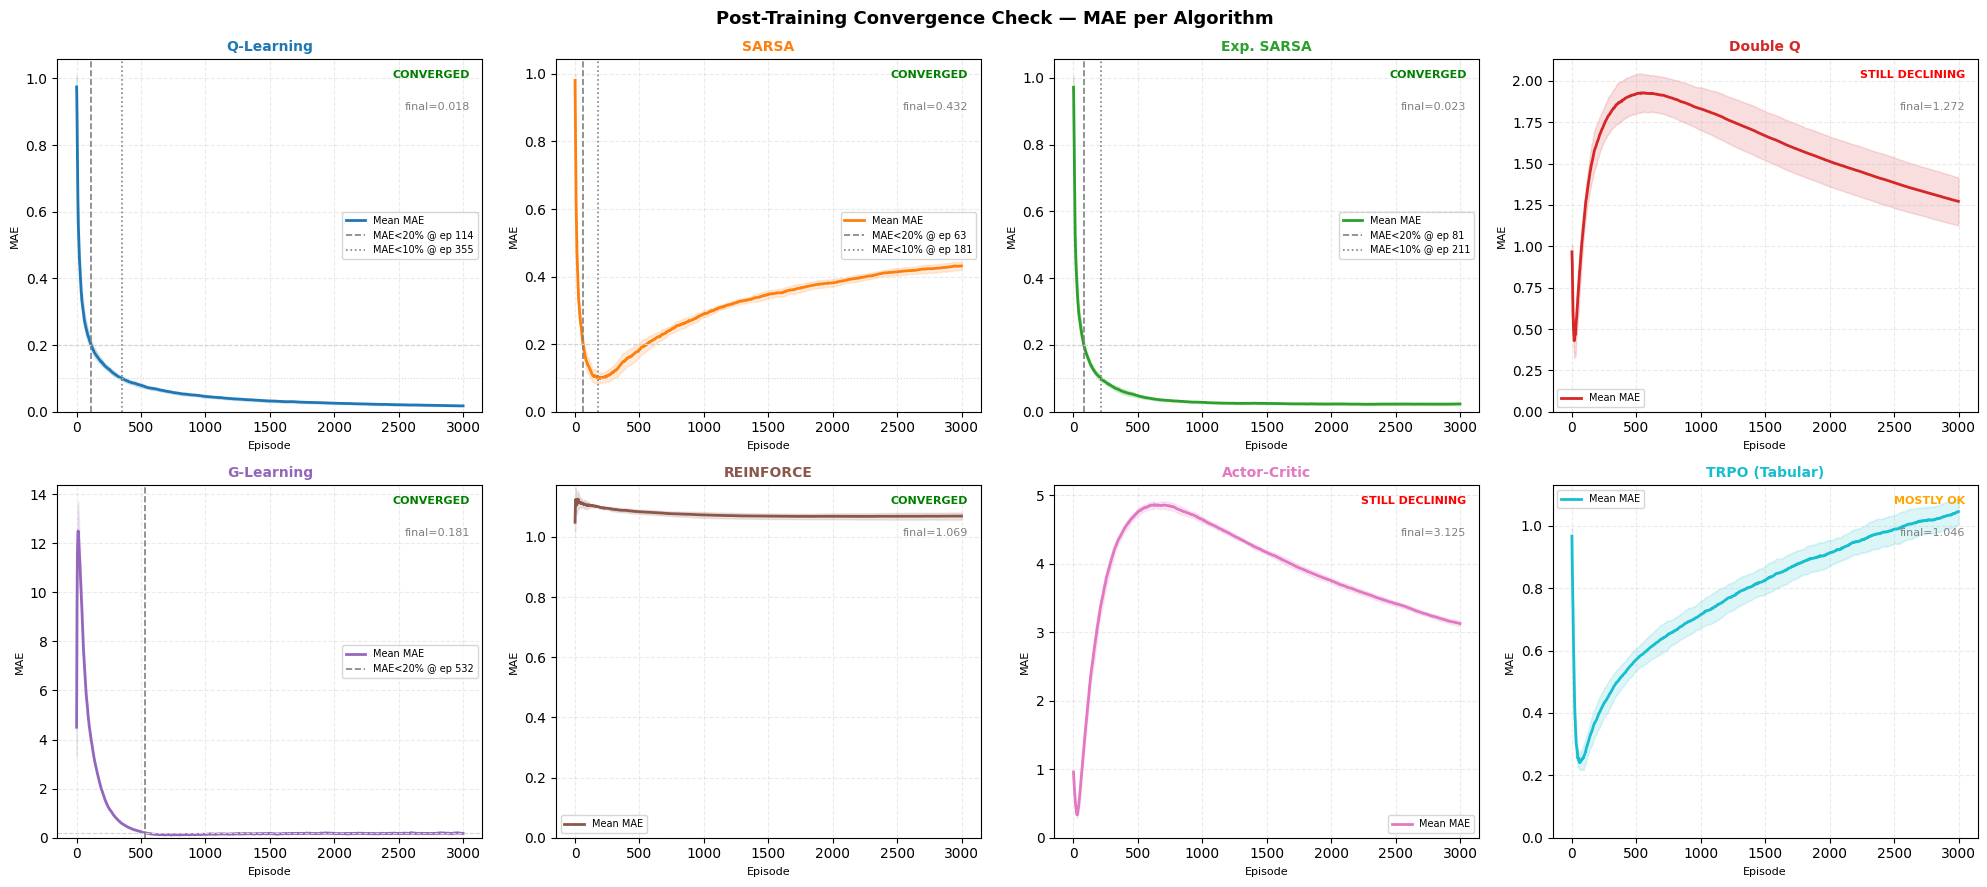


✅ Diagnostics complete. Plot saved to results/
  Share the text output above + diag_convergence_check.png
  with your team / paste to get hyperparameter advice.


In [84]:
# ================================================================
# CELL 9c — POST-TRAINING DIAGNOSTICS
# Run this immediately after Cell 9 completes.
# Checks: saves, NaN, convergence, bias direction, policy quality.
# ================================================================

import os

diag_results = {}
PASS = "✅"; WARN = "⚠️ "; FAIL = "❌"

print("=" * 70)
print("  POST-TRAINING DIAGNOSTICS")
print("=" * 70)

# ── 1. SAVE CHECK ────────────────────────────────────────────────
print("\n── 1. SAVE CHECK ───────────────────────────────────────────")
for algo in CONFIG["algos"]:
    path = f"{CONFIG['save_path']}{algo}.npy"
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"  {PASS}  {LABELS[algo]:22s}  saved  ({size_kb:.1f} KB)")
    else:
        print(f"  {FAIL}  {LABELS[algo]:22s}  FILE MISSING — results not saved!")

# ── 2. MEMORY CHECK ─────────────────────────────────────────────
print("\n── 2. IN-MEMORY CHECK ──────────────────────────────────────")
for algo in CONFIG["algos"]:
    if algo in ALL_RESULTS:
        print(f"  {PASS}  {LABELS[algo]:22s}  in ALL_RESULTS")
    else:
        print(f"  {FAIL}  {LABELS[algo]:22s}  MISSING from ALL_RESULTS")

# ── 3. NaN AUDIT ────────────────────────────────────────────────
print("\n── 3. NaN AUDIT ────────────────────────────────────────────")
for algo in CONFIG["algos"]:
    if algo not in ALL_RESULTS:
        continue
    M = ALL_RESULTS[algo]
    nan_bias = np.sum(np.isnan(M["bias"]))
    nan_mae  = np.sum(np.isnan(M["mae"]))
    nan_pe   = np.sum(np.isnan(M["policy_error"]))
    nan_be   = np.sum(np.isnan(M["bellman_error"]))
    total    = nan_bias + nan_mae + nan_be
    # policy_error has intentional NaNs (only computed every pe_every eps)
    expected_nans = CONFIG["num_runs"] * (
        CONFIG["num_episodes"] -
        len(range(0, CONFIG["num_episodes"], CONFIG["pe_every"]))
    )
    pe_unexpected = max(0, nan_pe - expected_nans)
    if total == 0 and pe_unexpected == 0:
        print(f"  {PASS}  {LABELS[algo]:22s}  no NaNs")
    else:
        flag = WARN if total < 50 else FAIL
        print(f"  {flag}  {LABELS[algo]:22s}  "
              f"bias:{nan_bias}  mae:{nan_mae}  "
              f"bellman:{nan_be}  policy_err(unexpected):{pe_unexpected}")

# ── 4. CONVERGENCE CHECK ─────────────────────────────────────────
print("\n── 4. CONVERGENCE CHECK (MAE slope over last 100 episodes) ─")
conv_data = {}
for algo in CONFIG["algos"]:
    if algo not in ALL_RESULTS:
        continue
    mn    = np.nanmean(ALL_RESULTS[algo]["mae"], axis=1)
    slope = float(mn[-1] - mn[-100])    # negative = still improving
    final = float(mn[-1])
    # Find first episode where MAE < thresholds
    conv20 = next((i for i, v in enumerate(mn) if v < 0.20),
                   CONFIG["num_episodes"])
    conv10 = next((i for i, v in enumerate(mn) if v < 0.10),
                   CONFIG["num_episodes"])
    conv_data[algo] = dict(slope=slope, final=final,
                           conv20=conv20, conv10=conv10)
    if abs(slope) < 0.005:
        status = f"{PASS} converged"
    elif abs(slope) < 0.02:
        status = f"{WARN} mostly converged (small slope)"
    else:
        status = f"{FAIL} STILL DECLINING — needs more episodes"
    print(f"  {status:32s}  {LABELS[algo]:22s}  "
          f"final_MAE={final:.4f}  slope={slope:+.4f}  "
          f"ep<20%={conv20}  ep<10%={conv10}")

# ── 5. BIAS DIRECTION CHECK ──────────────────────────────────────
print("\n── 5. BIAS DIRECTION CHECK (early vs late) ─────────────────")
print(f"  {'Algorithm':22s}  {'Early bias':>12s}  "
      f"{'Late bias':>12s}  {'Direction':>20s}")
print(f"  {'-'*22}  {'-'*12}  {'-'*12}  {'-'*20}")
for algo in CONFIG["algos"]:
    if algo not in ALL_RESULTS:
        continue
    b    = np.nanmean(ALL_RESULTS[algo]["bias"], axis=1)
    early = float(np.nanmean(b[:100]))
    late  = float(np.nanmean(b[-100:]))
    # Expected: Q-learning negative early. G-learning closer to zero.
    if algo == "q_learning":
        expected = "should be negative early"
        ok = PASS if early < -0.05 else WARN
    elif algo == "g_learning":
        expected = "should be closer to 0 than Q"
        q_early  = float(np.nanmean(
            np.nanmean(ALL_RESULTS["q_learning"]["bias"], axis=1)[:100]
        )) if "q_learning" in ALL_RESULTS else -999
        ok = PASS if early > q_early else WARN
    elif algo in ["sarsa", "expected_sarsa"]:
        expected = "less negative than Q-learning"
        q_early  = float(np.nanmean(
            np.nanmean(ALL_RESULTS["q_learning"]["bias"], axis=1)[:100]
        )) if "q_learning" in ALL_RESULTS else -999
        ok = PASS if early > q_early else WARN
    else:
        expected = "—"
        ok = "  "
    print(f"  {ok}  {LABELS[algo]:22s}  {early:+12.4f}  "
          f"{late:+12.4f}  {expected}")

# ── 6. POLICY QUALITY CHECK ──────────────────────────────────────
print("\n── 6. POLICY QUALITY (final policy evaluation error) ───────")
for algo in CONFIG["algos"]:
    if algo not in ALL_RESULTS:
        continue
    pe = ALL_RESULTS[algo]["policy_error"]
    # Get last non-NaN row average
    valid_rows = [i for i in range(CONFIG["num_episodes"])
                  if not np.all(np.isnan(pe[i, :]))]
    if not valid_rows:
        print(f"  {WARN}  {LABELS[algo]:22s}  no policy_error data")
        continue
    last_valid = valid_rows[-1]
    val = float(np.nanmean(pe[last_valid, :]))
    ok  = PASS if val < 0.30 else (WARN if val < 0.60 else FAIL)
    print(f"  {ok}  {LABELS[algo]:22s}  "
          f"policy_error={val:.4f}  "
          f"(at episode {last_valid})")

# ── 7. BELLMAN ERROR CONVERGENCE ────────────────────────────────
print("\n── 7. BELLMAN ERROR (should approach 0) ────────────────────")
for algo in CONFIG["algos"]:
    if algo not in ALL_RESULTS:
        continue
    be    = np.nanmean(ALL_RESULTS[algo]["bellman_error"], axis=1)
    early = float(np.nanmean(be[:100]))
    late  = float(np.nanmean(be[-100:]))
    ratio = late / (early + 1e-10)
    ok    = PASS if ratio < 0.5 else (WARN if ratio < 0.8 else FAIL)
    print(f"  {ok}  {LABELS[algo]:22s}  "
          f"early={early:.4f}  late={late:.4f}  "
          f"reduction={100*(1-ratio):.0f}%")

# ── 8. SUMMARY TABLE ────────────────────────────────────────────
print("\n── 8. FULL SUMMARY TABLE ───────────────────────────────────")
print(f"\n  {'Algorithm':22s} {'FinalMAE':>9s} {'FinalBias':>10s} "
      f"{'Ep→MAE<20%':>11s} {'Ep→MAE<10%':>11s} {'BellmanRed':>11s}")
print(f"  {'-'*22} {'-'*9} {'-'*10} {'-'*11} {'-'*11} {'-'*11}")
for algo in CONFIG["algos"]:
    if algo not in ALL_RESULTS or algo not in conv_data:
        continue
    cd   = conv_data[algo]
    b    = float(np.nanmean(np.nanmean(
               ALL_RESULTS[algo]["bias"], axis=1)[-100:]))
    be   = np.nanmean(ALL_RESULTS[algo]["bellman_error"], axis=1)
    bred = 100 * (1 - float(np.nanmean(be[-100:])) /
                  (float(np.nanmean(be[:100])) + 1e-10))
    print(f"  {LABELS[algo]:22s} {cd['final']:9.4f} {b:+10.4f} "
          f"{cd['conv20']:11d} {cd['conv10']:11d} {bred:10.0f}%")

# ── 9. CONVERGENCE PLOT ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Post-Training Convergence Check — MAE per Algorithm",
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, algo in enumerate(CONFIG["algos"]):
    ax = axes[i]
    if algo not in ALL_RESULTS:
        ax.text(0.5, 0.5, "MISSING", ha='center', va='center',
                transform=ax.transAxes, color='red', fontsize=14)
        ax.set_title(LABELS.get(algo, algo))
        continue

    mn = np.nanmean(ALL_RESULTS[algo]["mae"], axis=1)
    sd = np.nanstd(ALL_RESULTS[algo]["mae"],  axis=1)
    x  = np.arange(len(mn))

    ax.plot(x, mn, color=COLORS[algo], lw=2, label="Mean MAE")
    ax.fill_between(x, mn - sd, mn + sd,
                    alpha=0.15, color=COLORS[algo])

    # Mark convergence thresholds
    for thresh, ls, lbl in [(0.20, '--', '20%'), (0.10, ':', '10%')]:
        ep = next((j for j, v in enumerate(mn) if v < thresh), None)
        if ep:
            ax.axvline(ep, color='gray', ls=ls, lw=1.2,
                       label=f'MAE<{lbl} @ ep {ep}')
            ax.axhline(thresh, color='lightgray', ls=ls, lw=0.8)

    # Slope annotation
    cd = conv_data.get(algo, {})
    slope = cd.get('slope', 0)
    status = "CONVERGED" if abs(slope) < 0.005 else \
             "MOSTLY OK"  if abs(slope) < 0.02  else "STILL DECLINING"
    color  = 'green'      if abs(slope) < 0.005 else \
             'orange'     if abs(slope) < 0.02  else 'red'
    ax.text(0.97, 0.97, status, transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color=color,
            fontweight='bold')
    ax.text(0.97, 0.88, f"final={mn[-1]:.3f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='gray')

    ax.set_title(LABELS[algo], fontsize=10, fontweight='bold',
                 color=COLORS[algo])
    ax.set_xlabel("Episode", fontsize=8)
    ax.set_ylabel("MAE", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25, linestyle='--')
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(f"{CONFIG['save_path']}diag_convergence_check.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Diagnostics complete. Plot saved to results/")
print("=" * 70)
print("  Share the text output above + diag_convergence_check.png")
print("  with your team / paste to get hyperparameter advice.")
print("=" * 70)

In [85]:
# ================================================================
# CELL 9b — LOAD SAVED RESULTS  (uncomment to skip re-running)
# ================================================================
    
# ALL_RESULTS = {}
# for algo in CONFIG["algos"]:
#     path = f"{CONFIG['save_path']}{algo}.npy"
#     if os.path.exists(path):
#         ALL_RESULTS[algo] = np.load(path, allow_pickle=True).item()
#         print(f"✓ Loaded {LABELS[algo]}")
#     else:
#         print(f"✗ Missing: {algo} — run Cell 9 first")

In [86]:
# ================================================================
# CELL 10 — PLOTTING FUNCTIONS
# ================================================================

def smooth(arr, w=40):
    if len(arr) < w:
        return arr
    return np.convolve(arr, np.ones(w)/w, mode='valid')

def mean_std(data):
    """data shape: (episodes, runs) → two (episodes,) arrays."""
    return np.nanmean(data, axis=1), np.nanstd(data, axis=1)

def _plot_one(ax, algos, key, title, ylabel, w=40):
    for algo in algos:
        if algo not in ALL_RESULTS:
            continue
        mn, sd = mean_std(ALL_RESULTS[algo][key])
        valid  = ~np.isnan(mn)
        x, y, e = np.where(valid)[0], mn[valid], sd[valid]
        if w and key != "policy_error":
            y = smooth(mn, w);  x = np.arange(len(y));  e = smooth(sd, w)
        ax.plot(x, y, label=LABELS[algo], color=COLORS[algo], lw=1.5)
        ax.fill_between(x, y - 0.3*e, y + 0.3*e, alpha=0.12, color=COLORS[algo])
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Episode", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(0, color='k', lw=0.5, ls='--')


def plot_all_metrics(save=True):
    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle(
        "MCL775 — Model-Free RL Algorithm Comparison\n"
        "8×8 Stochastic Gridworld (Fox et al. 2016)",
        fontsize=13, fontweight='bold'
    )
    algos = CONFIG["algos"]
    _plot_one(axes[0,0], algos, "bias",
              "Fig 1: Empirical Bias (Signed Rel. Error)", "Bias", 40)
    _plot_one(axes[0,1], algos, "mae",
              "Fig 2: Mean Absolute Error in V", "MAE", 40)
    _plot_one(axes[0,2], algos, "policy_error",
              "Fig 3: Policy Evaluation Error", "Error", None)
    _plot_one(axes[1,0], algos, "bellman_error",
              "Fig 4: Bellman Error (avg |TD error|)", "|TD error|", 40)
    _plot_one(axes[1,1], algos, "cum_cost",
              "Fig 5: Per-Episode Cost", "Episode Cost", 40)
    _plot_one(axes[1,2], algos, "entropy",
              "Fig 6: Policy Entropy", "H(π)", 40)
    plt.tight_layout()
    if save:
        plt.savefig(f"{CONFIG['save_path']}fig_all_metrics.png",
                    dpi=150, bbox_inches='tight')
    plt.show()


def plot_pairwise(algo1, algo2, save=True):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Direct Comparison: {LABELS[algo1]} vs {LABELS[algo2]}",
                 fontsize=12, fontweight='bold')
    for ax, key, title, yl in zip(
        axes,
        ["bias",         "mae",          "policy_error"],
        ["Empirical Bias","MAE in V",     "Policy Eval Error"],
        ["Signed Bias",   "Abs. Error",   "Policy Error"]
    ):
        _plot_one(ax, [algo1, algo2], key, title, yl, 40)
    plt.tight_layout()
    if save:
        plt.savefig(
            f"{CONFIG['save_path']}fig_compare_{algo1}_vs_{algo2}.png",
            dpi=150, bbox_inches='tight')
    plt.show()


def plot_convergence_bar(threshold=0.20, save=True):
    """Episodes to reach MAE < threshold for each algorithm."""
    fig, ax = plt.subplots(figsize=(11, 5))
    algos, vals = [], []
    for algo in CONFIG["algos"]:
        if algo not in ALL_RESULTS:
            continue
        mn, _ = mean_std(ALL_RESULTS[algo]["mae"])
        idx    = np.where(mn < threshold)[0]
        algos.append(algo)
        vals.append(idx[0] if len(idx) > 0 else CONFIG["num_episodes"])

    bars = ax.bar([LABELS[a] for a in algos], vals,
                  color=[COLORS[a] for a in algos], alpha=0.85, edgecolor='k')
    ax.axhline(CONFIG["num_episodes"], color='red', ls='--',
               alpha=0.5, label='Did not converge')
    ax.set_title(f"Fig 7: Episodes to Reach MAE < {threshold:.0%}",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("Episodes")
    plt.xticks(rotation=20, ha='right')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=9)
    plt.tight_layout()
    if save:
        plt.savefig(f"{CONFIG['save_path']}fig_convergence_speed.png",
                    dpi=150, bbox_inches='tight')
    plt.show()


def plot_final_mae_bar(save=True):
    """Final performance bar chart (last 100 episodes)."""
    fig, ax = plt.subplots(figsize=(11, 5))
    algos, means, stds = [], [], []
    for algo in CONFIG["algos"]:
        if algo not in ALL_RESULTS:
            continue
        mn, sd = mean_std(ALL_RESULTS[algo]["mae"])
        algos.append(algo); means.append(np.mean(mn[-100:])); stds.append(np.mean(sd[-100:]))
    ax.bar([LABELS[a] for a in algos], means, yerr=stds,
           color=[COLORS[a] for a in algos], alpha=0.85, edgecolor='k', capsize=5)
    ax.set_title("Fig 8: Final MAE in V (Last 100 Episodes)",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("Mean Absolute Relative Error")
    plt.xticks(rotation=20, ha='right'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save:
        plt.savefig(f"{CONFIG['save_path']}fig_final_mae.png",
                    dpi=150, bbox_inches='tight')
    plt.show()

print("✓ Plot functions ready")

✓ Plot functions ready


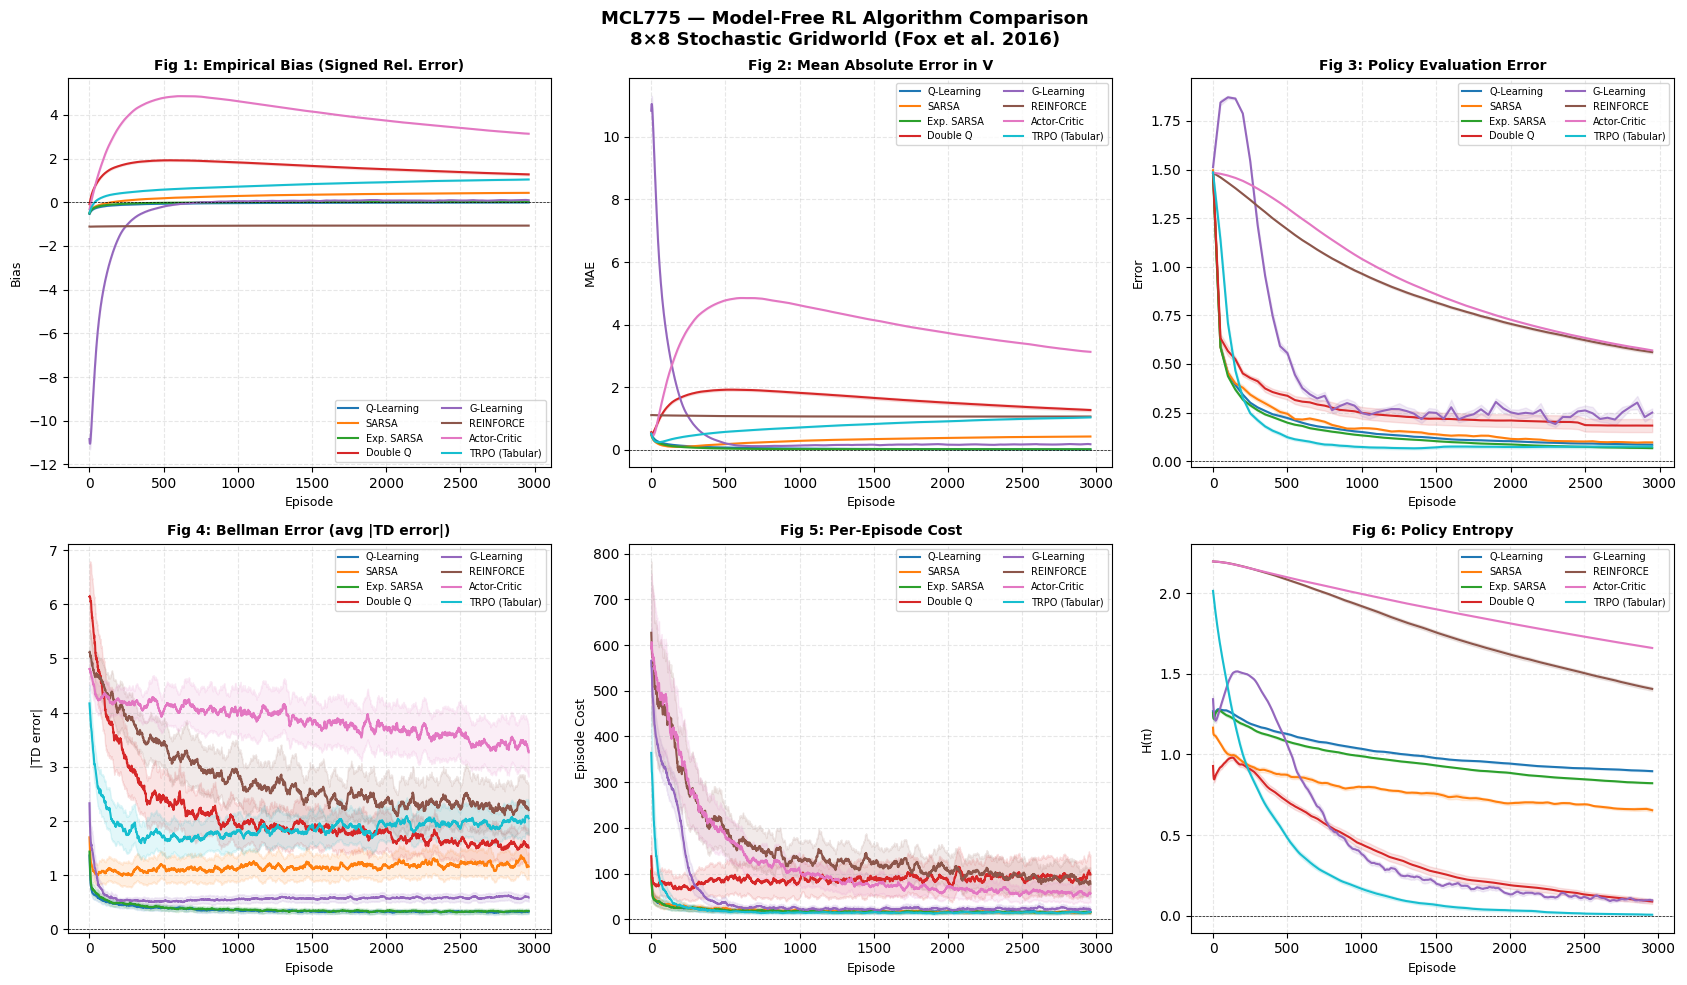

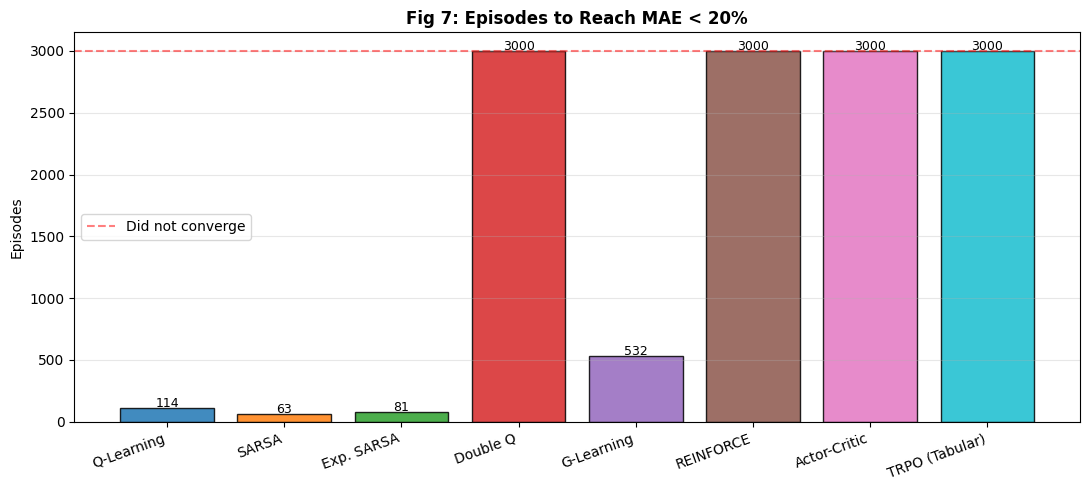

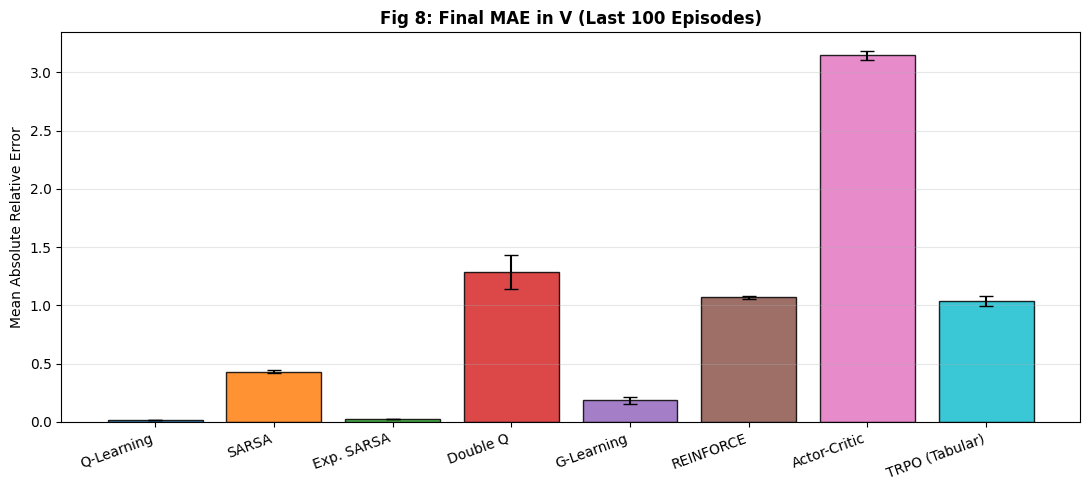

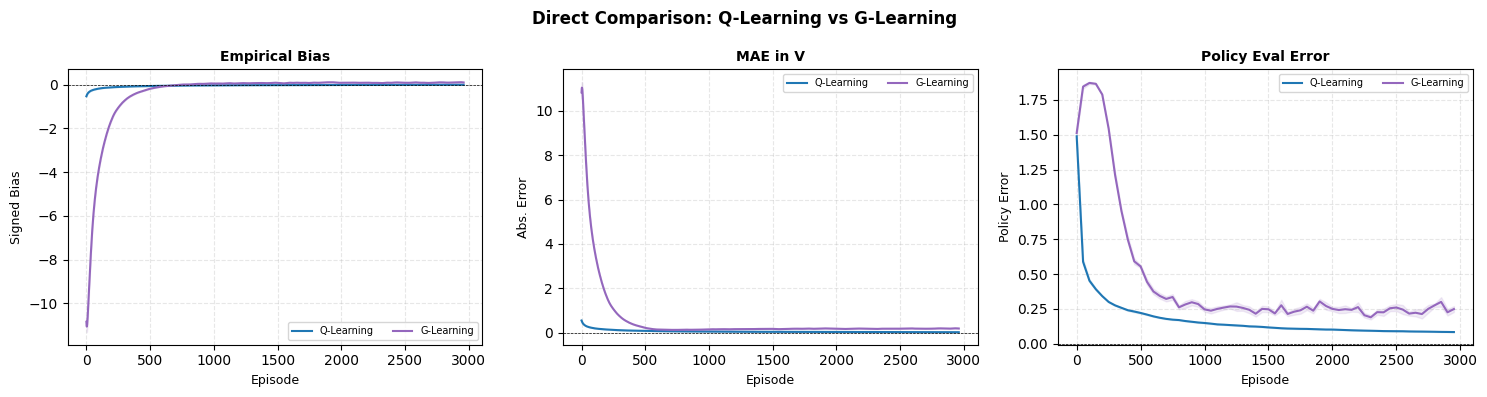

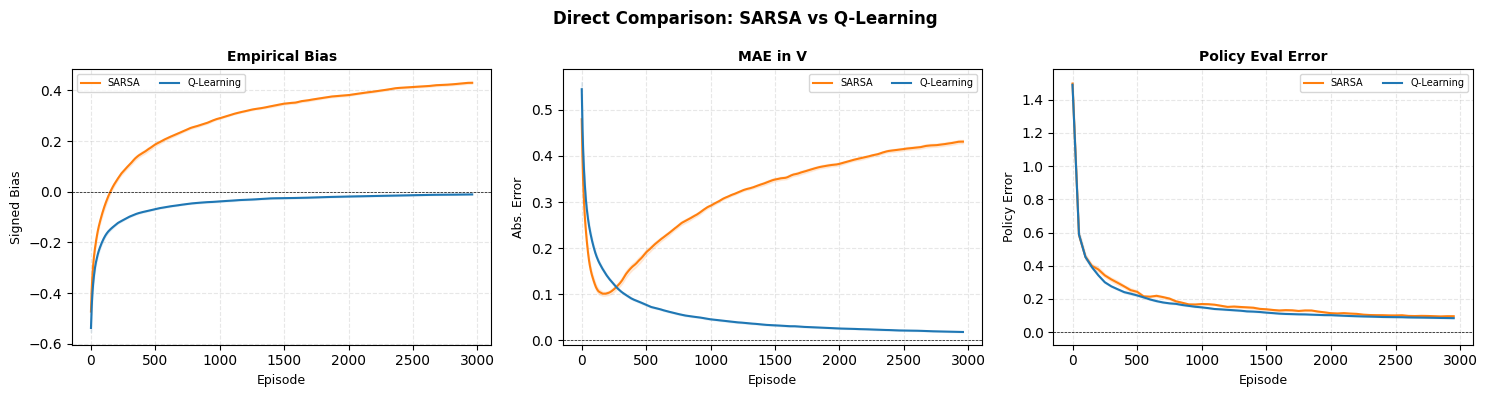

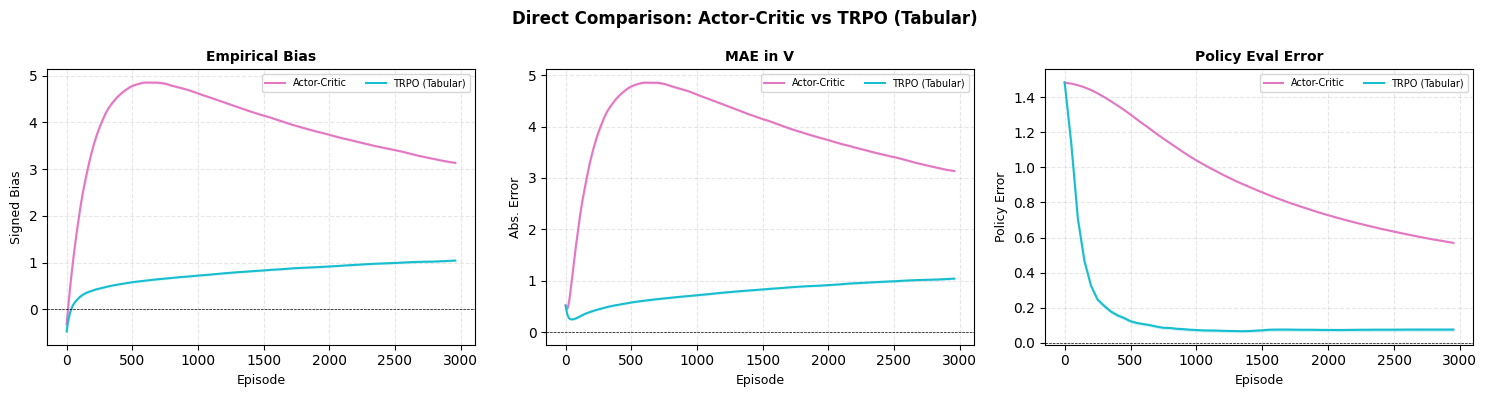

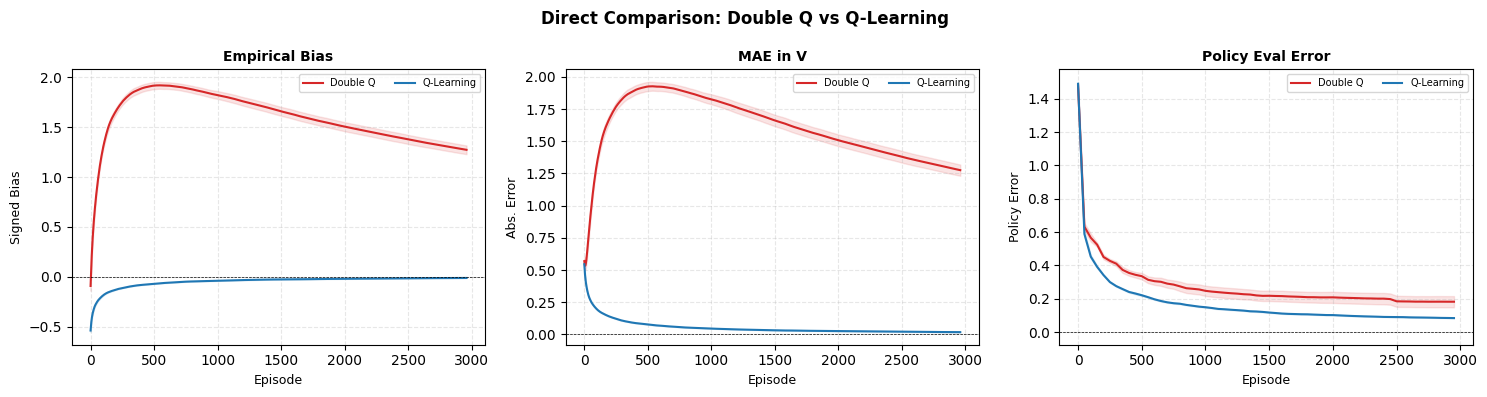

In [87]:
# ================================================================
# CELL 11 — GENERATE ALL COMPARISON PLOTS
# ================================================================

plot_all_metrics()
plot_convergence_bar()
plot_final_mae_bar()

# Key pairwise comparisons
plot_pairwise("q_learning", "g_learning")
plot_pairwise("sarsa",      "q_learning")
plot_pairwise("actor_critic","trpo")
plot_pairwise("double_q",   "q_learning")

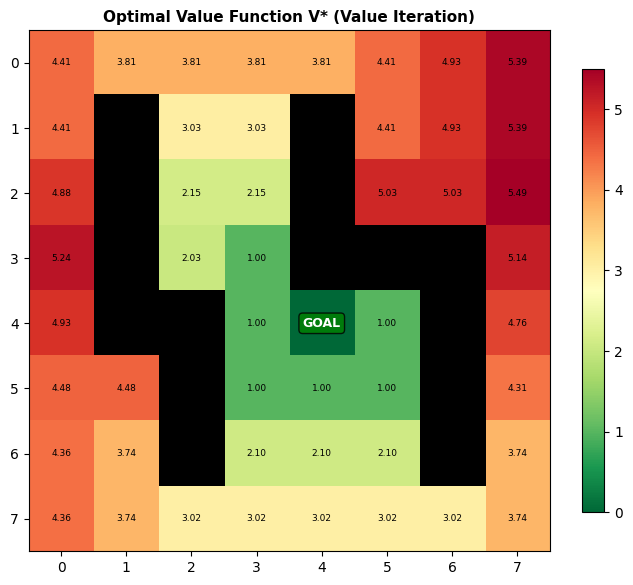

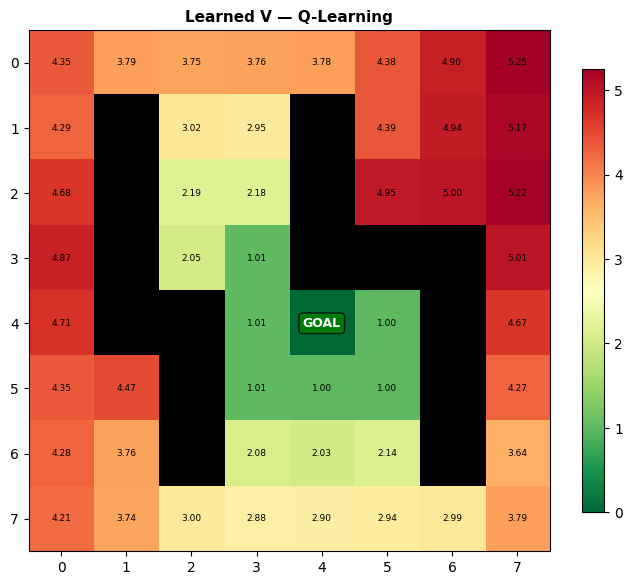

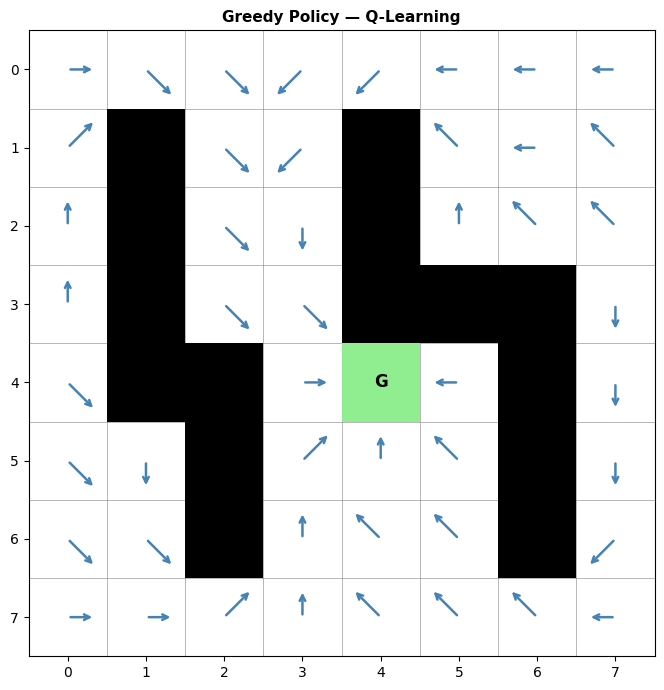

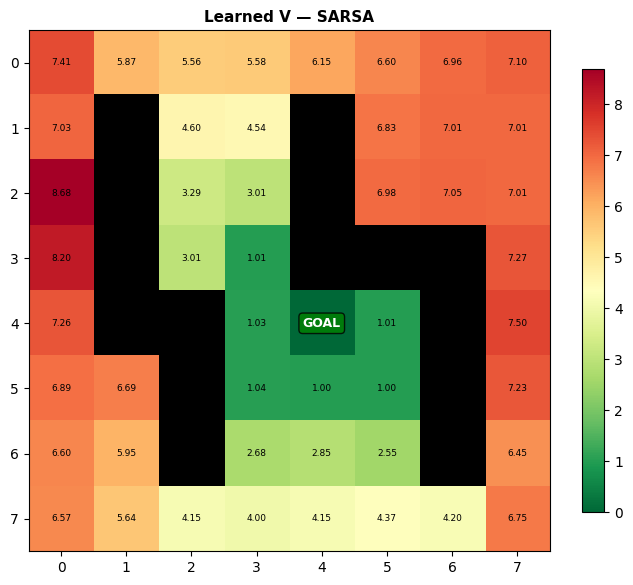

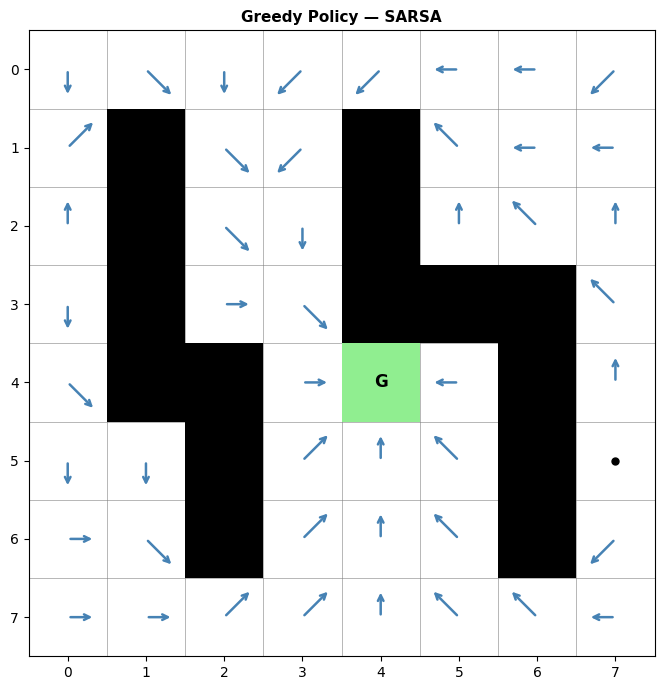

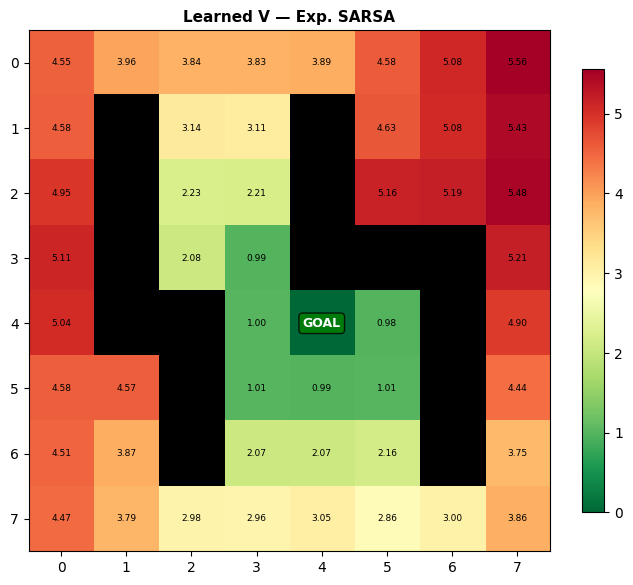

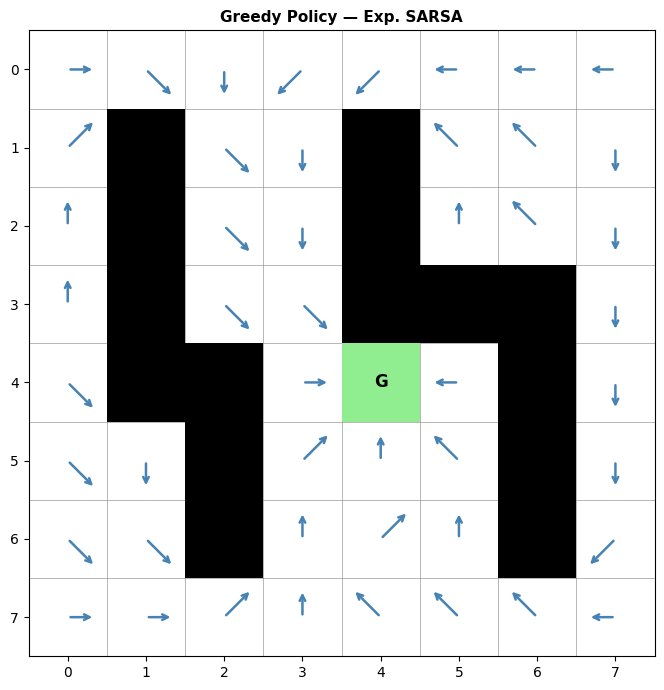

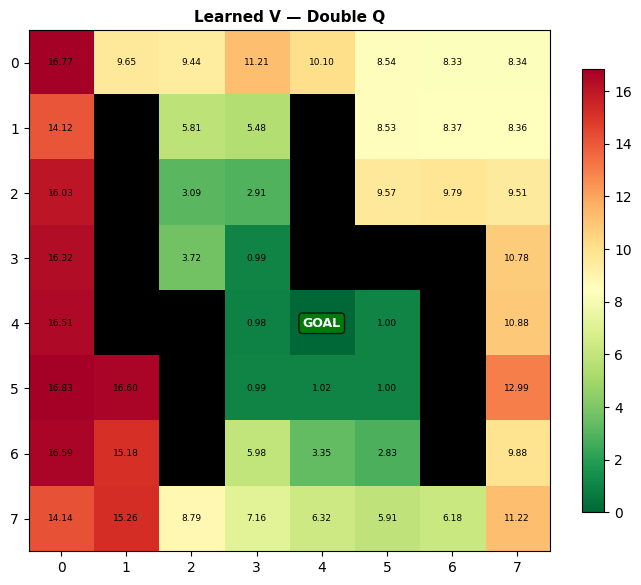

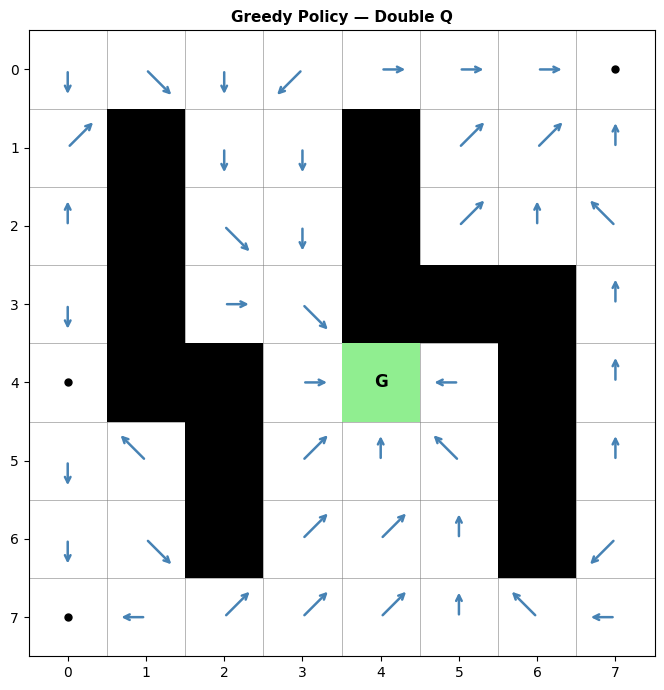

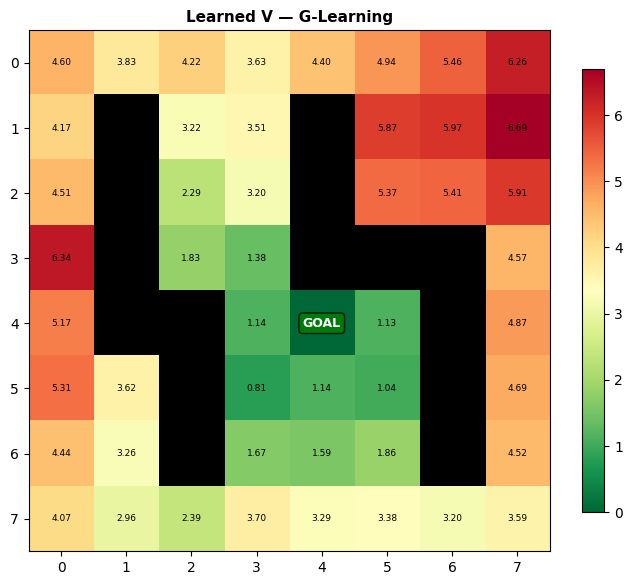

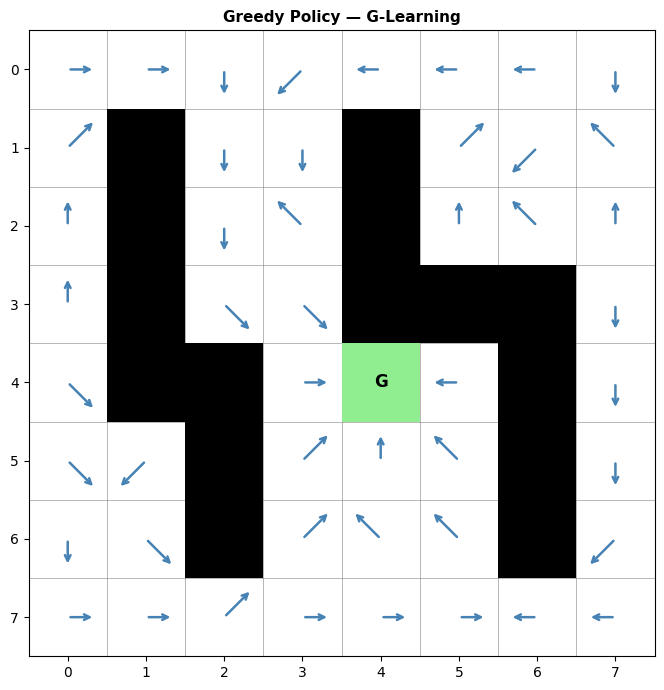

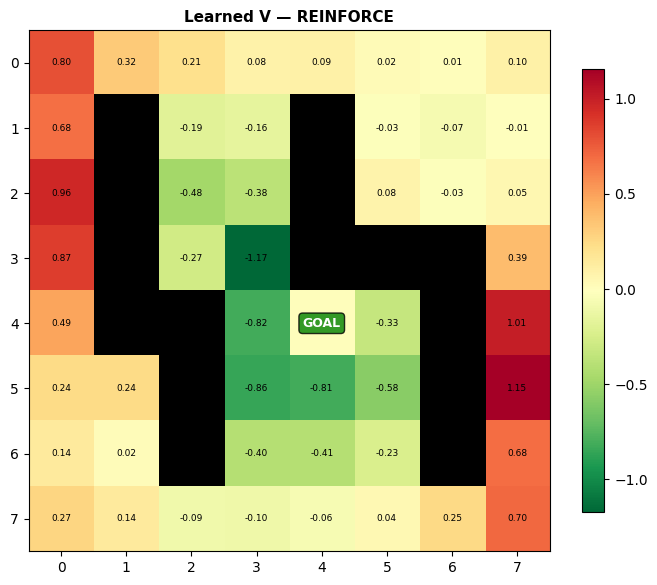

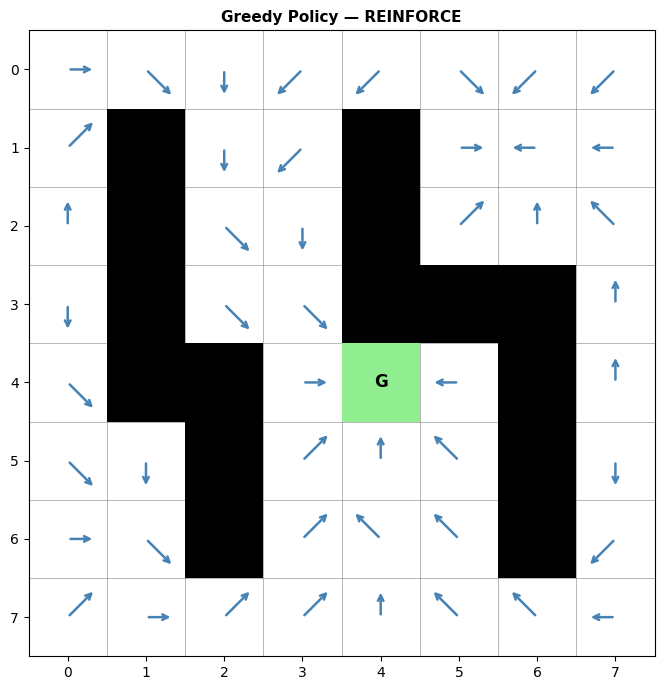

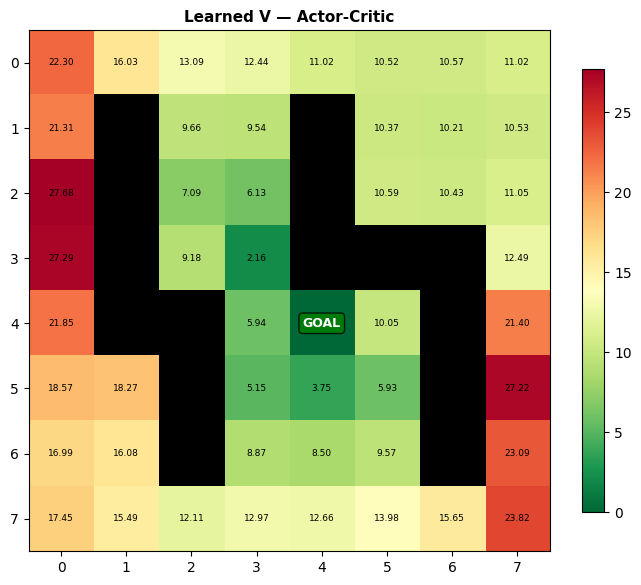

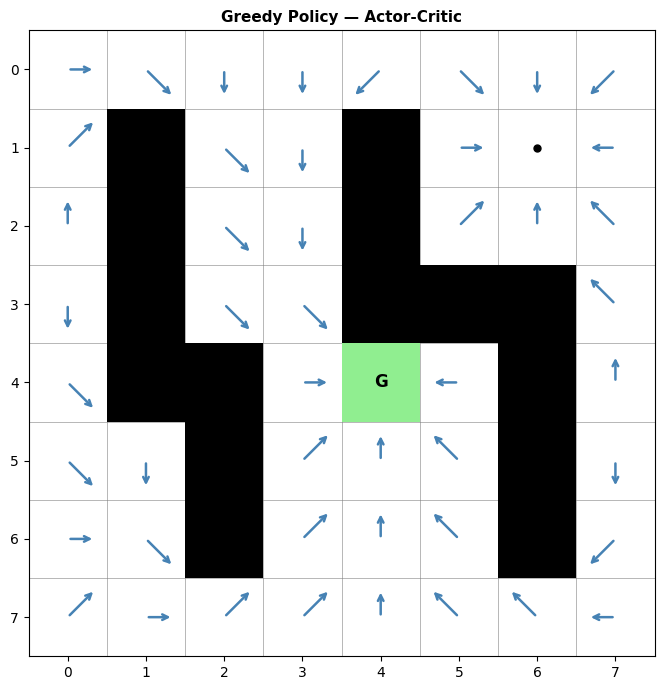

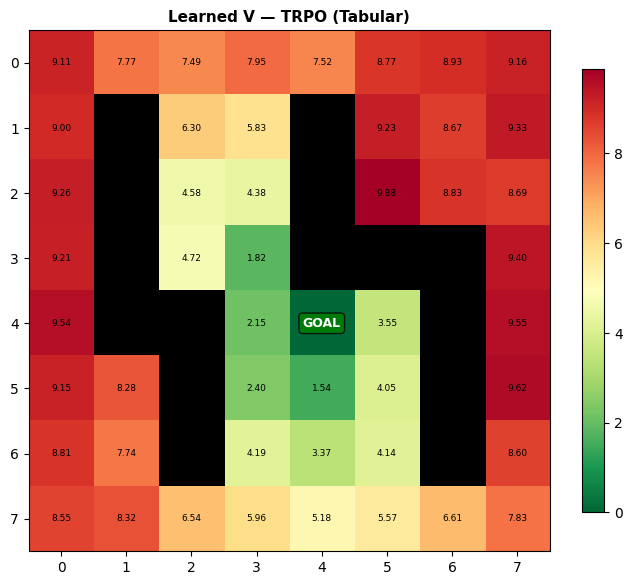

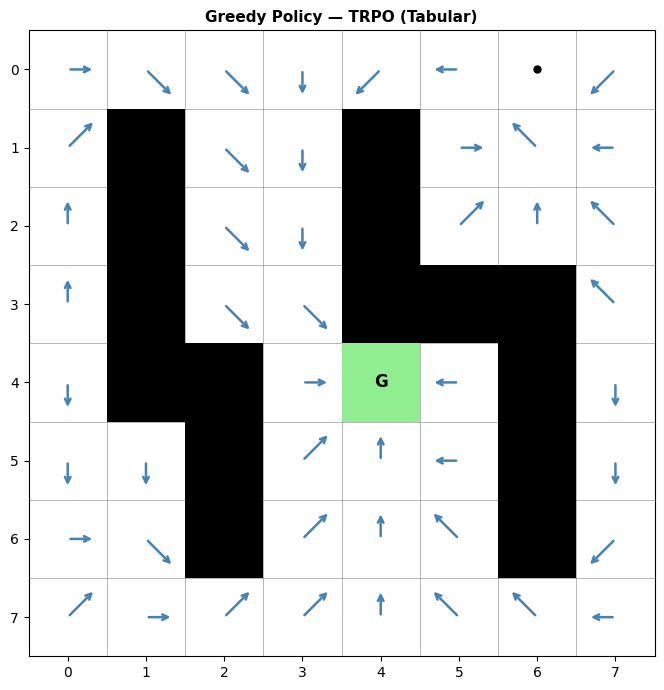

In [88]:
# ================================================================
# CELL 12 — GRIDWORLD VISUALIZATIONS
# ================================================================

def draw_grid_heatmap(values, title, cmap='RdYlGn_r', save_name=None):
    """Heatmap of any per-state scalar (V*, learned V, etc.)."""
    grid = np.full((8, 8), np.nan)
    for s in range(N_S):
        r, c = I2S[s]
        if s not in INV_FLAT:
            grid[r, c] = values[s]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(grid, cmap=cmap, aspect='equal',
                   vmin=np.nanmin(grid), vmax=np.nanmax(grid))

    # Black walls
    wall_mask = np.zeros((8, 8, 4))
    for s in INV_FLAT:
        r, c = I2S[s];  wall_mask[r, c] = [0,0,0,1]
    ax.imshow(wall_mask, aspect='equal')

    # Labels
    for s in VALID_STS:
        r, c = I2S[s]
        ax.text(c, r, f"{values[s]:.2f}", ha='center', va='center',
                fontsize=6.5, color='black')
    r_t, c_t = I2S[TERMINAL]
    ax.text(c_t, r_t, 'GOAL', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round', fc='green', alpha=0.8))

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{CONFIG['save_path']}{save_name}.png",
                    dpi=150, bbox_inches='tight')
    plt.show()


def draw_policy_arrows(policy, title, save_name=None):
    """Arrow plot showing greedy action at each valid state."""
    ARROW = {
        0:(0,-0.35), 1:(0.35,-0.35), 2:(0.35,0),  3:(0.35,0.35),
        4:(0,0.35),  5:(-0.35,0.35), 6:(-0.35,0), 7:(-0.35,-0.35), 8:(0,0)
    }
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(7.5, -0.5)   # inverted y
    ax.set_aspect('equal')

    for i in range(9):
        ax.axhline(i - 0.5, color='gray', lw=0.4)
        ax.axvline(i - 0.5, color='gray', lw=0.4)

    for s in range(N_S):
        r, c = I2S[s]
        if s in INV_FLAT:
            ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1,
                         fc='black', zorder=2))
        elif s == TERMINAL:
            ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1,
                         fc='lightgreen', zorder=2))
            ax.text(c, r, 'G', ha='center', va='center',
                    fontsize=12, fontweight='bold', zorder=3)
        else:
            a_best = np.argmax(policy[s, :])
            dx, dy = ARROW[a_best]
            if a_best != 8:
                ax.annotate('', xy=(c+dx, r+dy), xytext=(c, r),
                            arrowprops=dict(arrowstyle='->', color='steelblue',
                                           lw=1.8), zorder=3)
            else:
                ax.plot(c, r, 'ko', ms=5, zorder=3)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    plt.tight_layout()
    if save_name:
        plt.savefig(f"{CONFIG['save_path']}{save_name}.png",
                    dpi=150, bbox_inches='tight')
    plt.show()


# --- V* ground truth ---
draw_grid_heatmap(V_STAR, "Optimal Value Function V* (Value Iteration)",
                  save_name="viz_v_star")

# --- Learned V and policy per algorithm ---
for algo in CONFIG["algos"]:
    if algo not in ALL_RESULTS or ALL_RESULTS[algo]["final_V"] is None:
        continue
    draw_grid_heatmap(
        ALL_RESULTS[algo]["final_V"],
        f"Learned V — {LABELS[algo]}",
        save_name=f"viz_V_{algo}"
    )
    draw_policy_arrows(
        ALL_RESULTS[algo]["final_policy"],
        f"Greedy Policy — {LABELS[algo]}",
        save_name=f"viz_policy_{algo}"
    )